In [228]:
# Random Forest

In [230]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [232]:
df = pd.read_excel("glass.xlsx",sheet_name=1)
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [234]:
df.shape

(214, 10)

In [236]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [238]:
## The dataset contains only numeric data, hence doesnt need to apply any encoding methods.

In [240]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [242]:
df.duplicated().sum()

np.int64(1)

In [244]:
df.drop_duplicates(inplace=True)

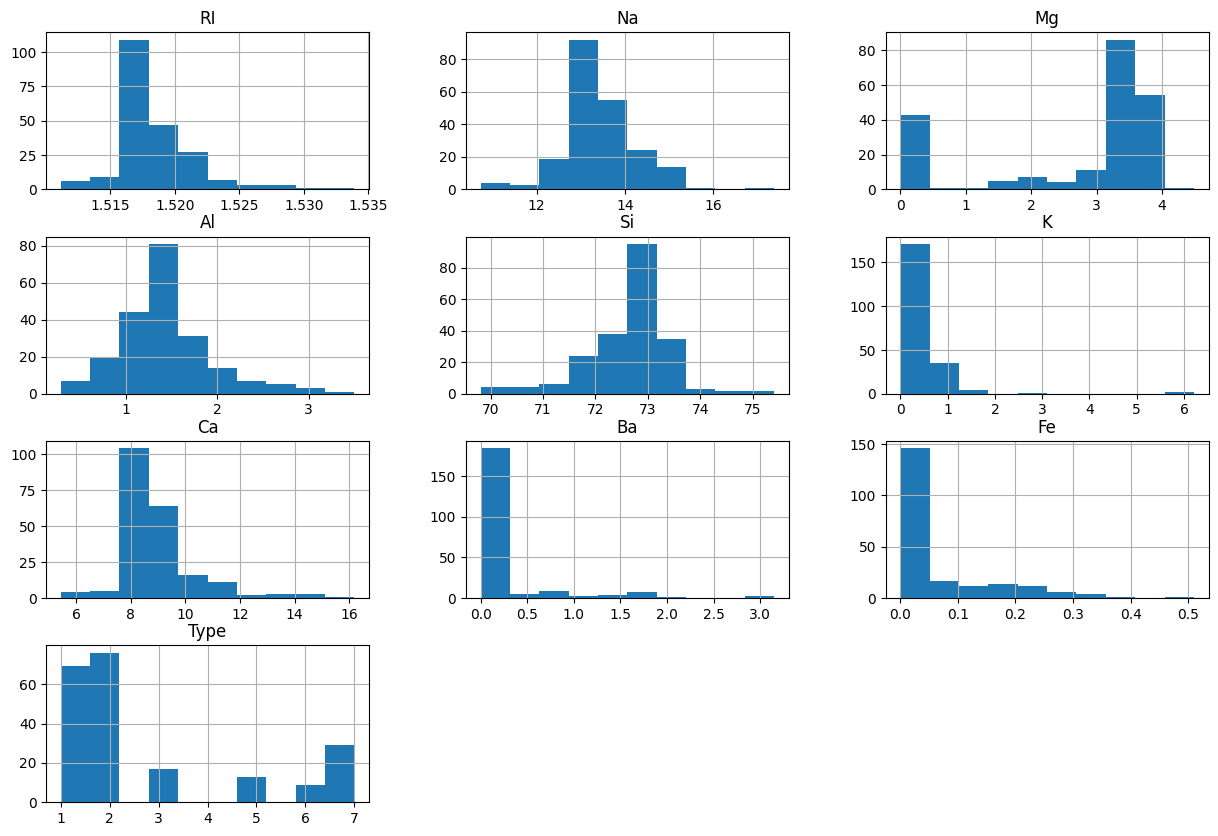

In [246]:
df.hist(figsize=(15,10))
plt.show()

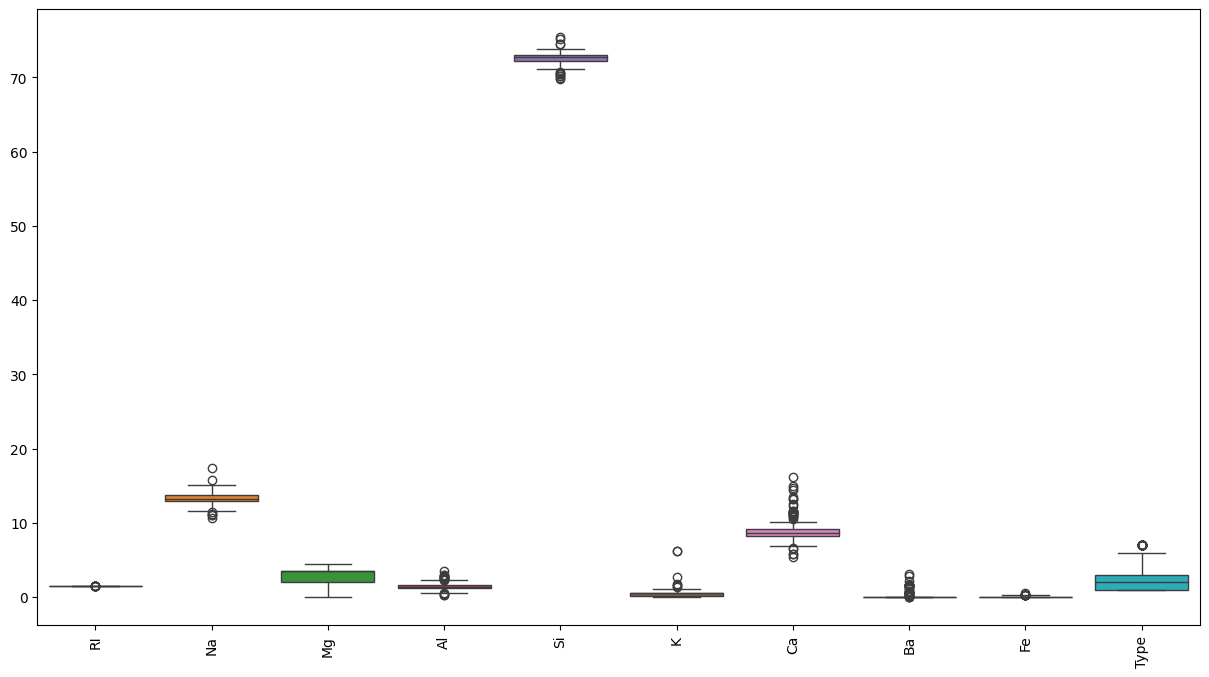

In [247]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

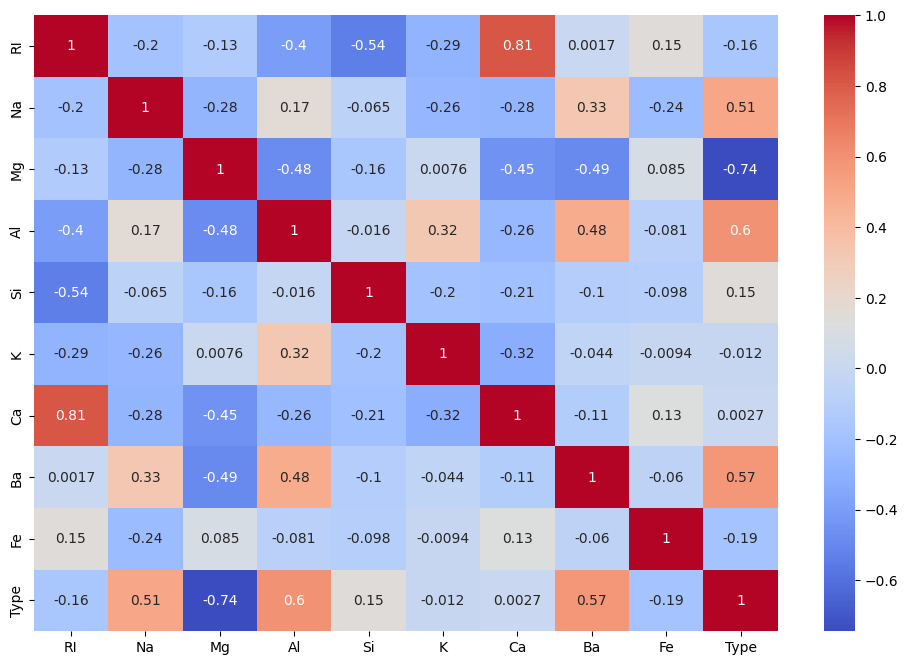

In [248]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [249]:
print(df['Type'].value_counts())

Type
2    76
1    69
7    29
3    17
5    13
6     9
Name: count, dtype: int64


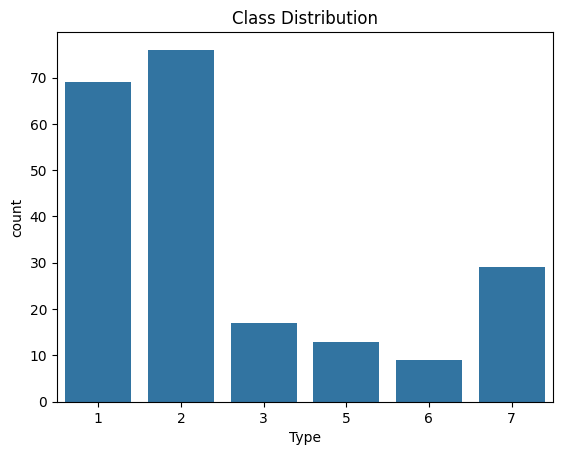

In [250]:
sns.countplot(x=df['Type'])
plt.title("Class Distribution")
plt.show()

In [251]:
X = df.drop('Type', axis=1)
y = df['Type']

In [253]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [255]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [262]:
## Random Forest Model

In [264]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

In [266]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [268]:
rf_pred = rf_model.predict(X_test)

In [270]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8372093023255814


In [272]:
print("Random Forest Precision:", precision_score(y_test, rf_pred, average='weighted'))

Random Forest Precision: 0.8496124031007751


In [274]:
print("Random Forest Recall:", recall_score(y_test, rf_pred, average='weighted'))

Random Forest Recall: 0.8372093023255814


In [276]:
print("Random Forest F1 Score:", f1_score(y_test, rf_pred, average='weighted'))

Random Forest F1 Score: 0.8381570314208645


In [278]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           1       0.80      0.86      0.83        14
           2       0.80      0.80      0.80        15
           3       1.00      0.67      0.80         3
           5       1.00      1.00      1.00         3
           6       0.67      1.00      0.80         2
           7       1.00      0.83      0.91         6

    accuracy                           0.84        43
   macro avg       0.88      0.86      0.86        43
weighted avg       0.85      0.84      0.84        43



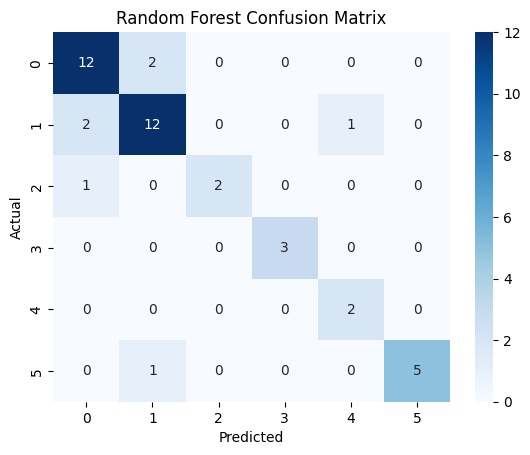

In [280]:
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [282]:
## Bagging Model

In [284]:
bag_model = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42)

In [286]:
bag_model.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",100
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [287]:
bag_pred = bag_model.predict(X_test)

In [290]:
print("Bagging Accuracy:", accuracy_score(y_test, bag_pred))

Bagging Accuracy: 0.7906976744186046


In [292]:
print("Bagging F1 Score:", f1_score(y_test, bag_pred, average='weighted'))

Bagging F1 Score: 0.7887853926346309


In [294]:
## Boost Model

In [296]:
boost_model = AdaBoostClassifier(n_estimators=100, random_state=42)

In [298]:
boost_model.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [300]:
boost_pred = boost_model.predict(X_test)

In [302]:
print("Boosting Accuracy:", accuracy_score(y_test, boost_pred))

Boosting Accuracy: 0.3953488372093023


In [304]:
print("Boosting F1 Score:", f1_score(y_test, boost_pred, average='weighted'))

Boosting F1 Score: 0.3857333020123717


In [306]:
## Model Comparison

In [308]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Bagging', 'Boosting'],
    'Accuracy': [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, bag_pred),
        accuracy_score(y_test, boost_pred)
    ],
    'F1 Score': [
        f1_score(y_test, rf_pred, average='weighted'),
        f1_score(y_test, bag_pred, average='weighted'),
        f1_score(y_test, boost_pred, average='weighted')
    ]
})

print(comparison)

           Model  Accuracy  F1 Score
0  Random Forest  0.837209  0.838157
1        Bagging  0.790698  0.788785
2       Boosting  0.395349  0.385733


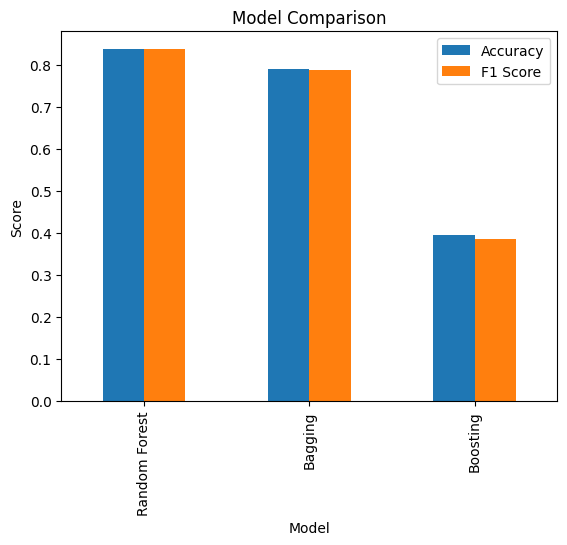

In [310]:
comparison.plot(x='Model', y=['Accuracy','F1 Score'], kind='bar')
plt.ylabel("Score")
plt.title("Model Comparison")
plt.show()

In [312]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)
print(importance)

  Feature  Importance
2      Mg    0.182210
6      Ca    0.139319
1      Na    0.133324
5       K    0.130525
3      Al    0.117971
0      RI    0.107215
4      Si    0.085644
7      Ba    0.080428
8      Fe    0.023365


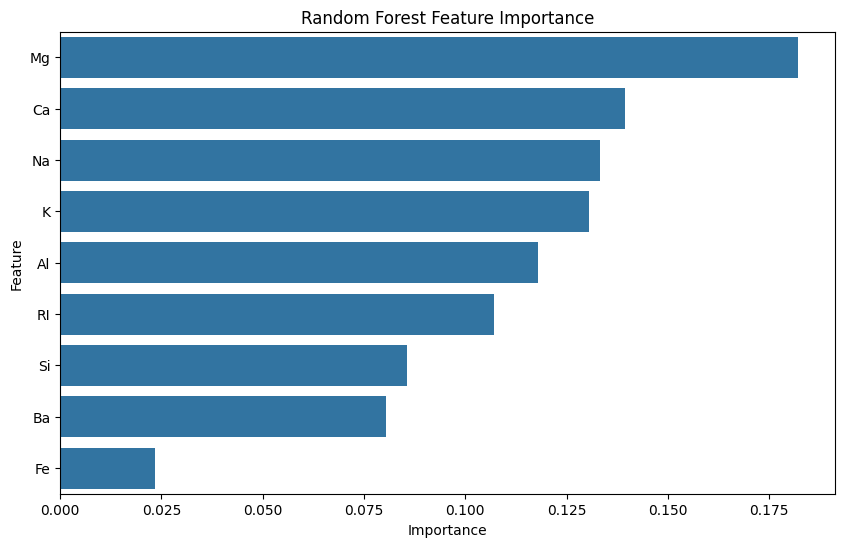

In [314]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title("Random Forest Feature Importance")
plt.show()

In [316]:
##-> 1. Random Forest successfully classified glass types using chemical composition features.
##-> 2. Class imbalance existed in the dataset, and class weighting helped improve minority class handling.
##-> 3. Bagging improved model stability by reducing variance, while Boosting focused on correcting previous classification errors.
##-> 4. Random Forest generally achieved strong overall performance because it combines multiple decision trees with bootstrap aggregation.
##-> 5. Feature importance analysis identified the most influential chemical attributes affecting glass classification.

In [210]:
# Interview Questions and Answers

## 1. Difference Between Bagging and Boosting
##-> Bagging trains multiple models independently using bootstrap samples and combines their outputs to reduce variance. Boosting trains models sequentially, where each model focuses on correcting errors made by previous models, helping reduce bias.

## 2. Handling Imbalanced Data
##-> Imbalanced data can be handled using techniques such as class weighting, oversampling, undersampling, or SMOTE. In this assignment, class_weight='balanced' was used to give higher importance to minority classes during training.